<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/SOAL_ADS_BK_11Januari_(A11_2022_14105_Eustachius_Dito).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><img src="https://dinus.ac.id/wp-content/uploads/2024/11/Logo-Web-Udinus-Putih.png"  width="400">


# Jawaban Ujian BK Associate Data Scientist - Teknik Informatika S1 - 11 Januari 2025
</center>

PANDUAN:
- **WAJIB MENGISI SEMUA UNIT**
- DIPERBOLEHKAN MEMBUKA FILE LAMPAU, TAPI TIDAK BOLEH MENGGUNAKAN CHATGPT, GEMINI, CLAUDE, DAN LLM LAINNYA
- JIKA SUDAH SELESAI, SILAKAN MENGABARI PENGUJI UNTUK DINILAI

# Latar Belakang Masalah
Kesehatan adalah pilar utama kehidupan. Salah satu ancaman serius yang dihadapi masyarakat saat ini adalah **gagal jantung**, penyakit kronis yang menjadi penyebab utama kematian di seluruh dunia. Gagal jantung terjadi ketika jantung tidak mampu memompa darah yang cukup untuk memenuhi kebutuhan tubuh, yang sering kali berujung pada komplikasi yang mengancam jiwa.

Menyadari pentingnya penanganan dini dan akurat terhadap penyakit ini, dunia medis dan teknologi bekerja sama untuk menghadirkan solusi berbasis data. Salah satu langkah penting adalah pemanfaatan dataset medis untuk membangun model prediksi yang dapat membantu dokter dan tenaga medis dalam mengidentifikasi pasien berisiko tinggi.

Dataset **Heart Failure Clinical Records**, yang terdiri dari 299 catatan medis pasien gagal jantung, menyediakan data penting yang mencakup berbagai faktor seperti `age`, `anaemia`, `creatinine_phosphokinase`, `diabetes`, `ejection_fraction`, `high_blood_pressure`, `platelets`, `serum_creatinine`, `serum_sodium`, `sex`, `smoking`, `time`, `death_event`. Informasi ini menjadi fondasi untuk mengembangkan model prediktif yang akurat.

# Tujuan Ujian Sertifikasi
Tujuan utama dari analisis dataset ini adalah:
1. **Mengidentifikasi variabel kunci** yang memengaruhi risiko mortalitas pasien gagal jantung.
2. **Membangun model prediktif** yang dapat membantu memprediksi kelangsungan hidup pasien gagal jantung.

Dengan hasil analisis ini, diharapkan dataset dapat memberikan wawasan yang berharga kepada rumah sakit, tenaga medis, dan pembuat kebijakan dalam mengurangi angka kematian akibat gagal jantung.

# Terkait Dataset
- **Sumber Data**: [Heart Failure Clinical Records Dataset - UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records)
- **Jumlah Sampel Data**: 299 pasien
- **Jumlah Atribut**: 13 atribut, meliputi: `age`, `anaemia`, `creatinine_phosphokinase`, `diabetes`, dan lainnya.
- **Label**: Kematian pasien selama periode tindak lanjut (0 = hidup, 1 = meninggal).

# Pendekatan Analisis
Untuk mendukung analisis dataset ini, akan dibuat skema komparasi model prediksi yang dilakukan dengan dua pendekatan berbeda:

1. **Menggunakan Dua Fitur Penting**: Model akan dibangun hanya dengan menggunakan dua fitur kunci, yaitu `serum_creatinine` dan `ejection_fraction`. Kedua fitur ini dipilih karena memiliki hubungan signifikan dengan fungsi ginjal dan keseimbangan elektrolit yang berdampak pada kondisi gagal jantung.

2. **Menggunakan Semua Fitur**: Model akan dibangun dengan memanfaatkan semua 13 fitur yang tersedia dalam dataset untuk melihat seberapa besar peningkatan akurasi dan performa jika semua informasi digunakan.

Studi ini berfokus pada dataset 299 pasien yang dikumpulkan pada tahun 2015 untuk mengevaluasi apakah dua faktor klinis utama **serum creatinine** dan **ejection fraction** cukup, untuk memprediksi kelangsungan hidup pasien dengan lebih akurat dibandingkan menggunakan seluruh data fitur klinis.




## LOAD LIBRARY - MASUKKAN LIBRARY PYTHON YANG AKAN ANDA GUNAKAN

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## BAB 1 - (J.62DMI00.004.1) Mengumpulkan data
- Load Data dan Ganti nama kolom yang masih berupa index dan ganti menjadi berikut pada dataframe :

  age, anaemia, creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine, serum_sodium, sex, smoking,time,death_event

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/BK_20des2025/heart_failure_clinical_records_dataset_missing_new.csv')

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,75.0,0,582.0,0,20.0,1,265000.00,1.9,130,1,0.0,4,1
1,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136,1,0.0,6,1
2,65.0,0,146.0,0,20.0,0,162000.00,1.3,129,1,1.0,7,1
3,50.0,1,111.0,0,20.0,0,210000.00,1.9,137,1,0.0,7,1
4,65.0,1,160.0,1,NaN,0,327000.00,2.7,116,0,0.0,8,1


In [ ]:
cols =['age', 'anaemia', 'creatinine_phosphokinase','diabetes','ejection_fraction','high_blood_pressure','platelets','serum_creatinine', 'serum_sodium', 'sex', 'smoking','time','death_event']

# Mengganti nama kolom dataframe dengan cols
df.columns = cols

In [ ]:
# Tampilkan data setelah nama kolom berhasil diganti.
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582.0,0,20.0,1,265000.00,1.9,130,1,0.0,4,1
1,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136,1,0.0,6,1
2,65.0,0,146.0,0,20.0,0,162000.00,1.3,129,1,1.0,7,1
3,50.0,1,111.0,0,20.0,0,210000.00,1.9,137,1,0.0,7,1
4,65.0,1,160.0,1,NaN,0,327000.00,2.7,116,0,0.0,8,1


## BAB 2 – (J.62DMI00.005.1) Menelaah data

- Pada tahap ini, kita akan menelaah data yang ada pada dataset Heart Failure Prediction. Kita akan melihat informasi data, statistik deskriptif, dan distribusi data.

In [ ]:
# Melihat Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       269 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  284 non-null    float64
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         296 non-null    float64
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 269 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   275 non-null    float64
 11  time                      299 non-null    int64  
 12  death_event               299 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 30.5 KB


In [ ]:
# Melihat Deskripsi statistik
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
count,269.000000,299.000000,284.000000,299.000000,296.000000,299.000000,269.000000,299.00000,299.000000,299.000000,275.000000,299.000000,299.00000
mean,61.057004,0.431438,570.947183,0.418060,38.064189,0.351171,261182.344796,1.39388,136.625418,0.648829,0.323636,130.260870,0.32107
std,12.096525,0.496107,973.348989,0.494067,11.778720,0.478136,98953.721912,1.03451,4.412477,0.478136,0.468716,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.000000,4.000000,0.00000
25%,51.000000,0.000000,115.000000,0.000000,30.000000,0.000000,211000.000000,0.90000,134.000000,0.000000,0.000000,73.000000,0.00000
50%,60.000000,0.000000,247.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.000000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,302000.000000,1.40000,140.000000,1.000000,1.000000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.000000,285.000000,1.00000


- Nominal Feature

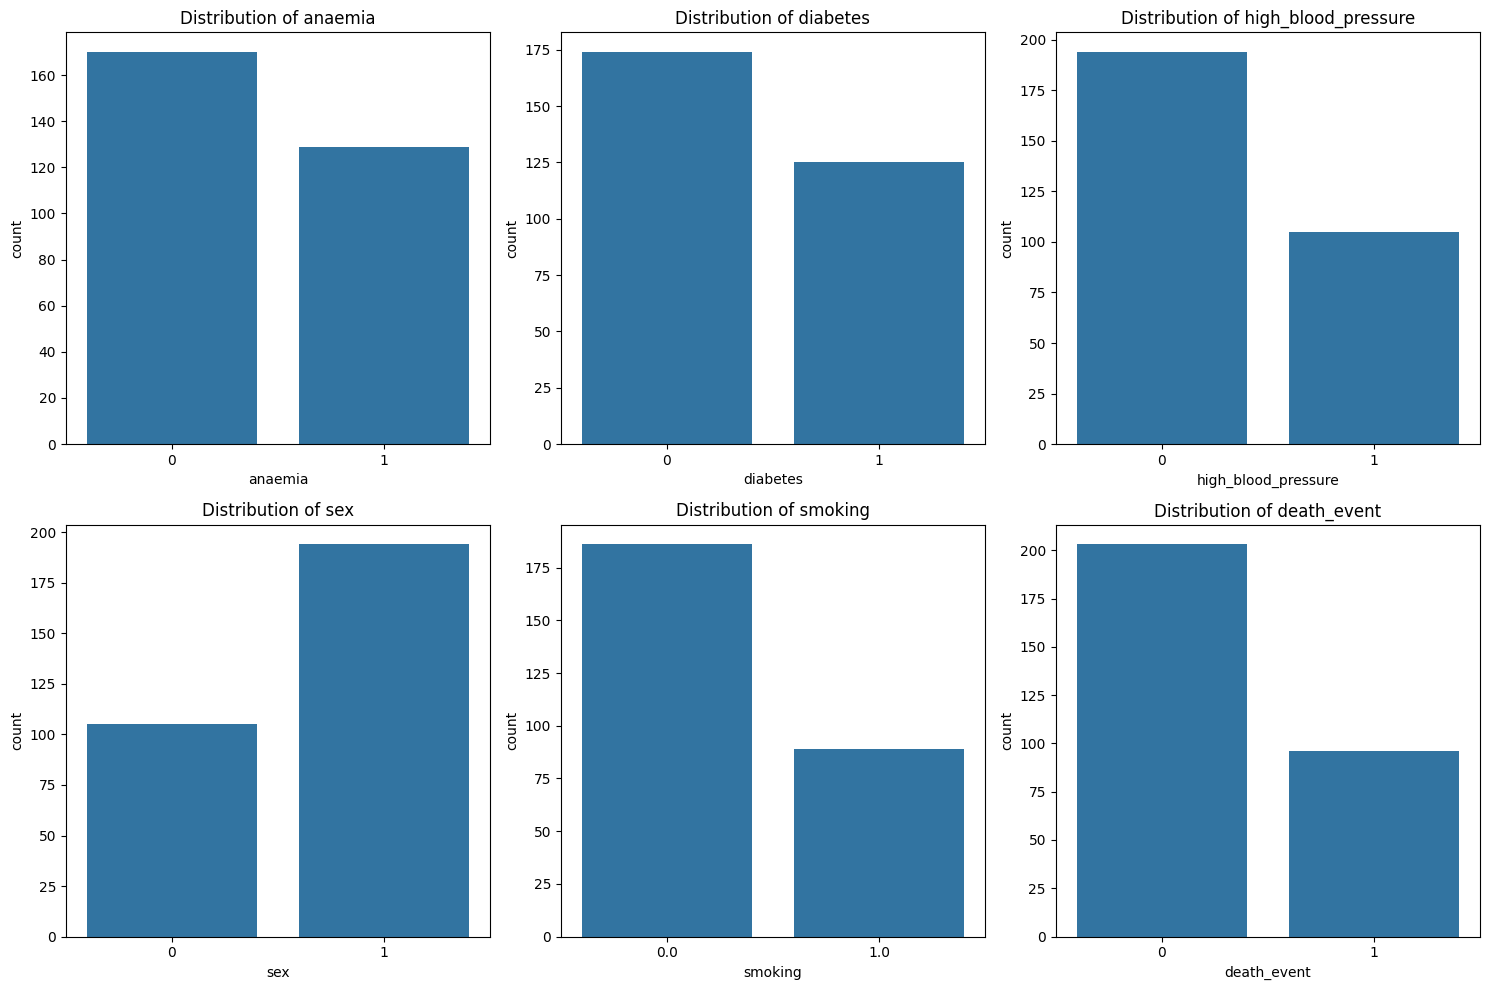

In [ ]:
# Visualisasikan fitur nominal / kategorikal misal (menggunakan countplot)
nominal_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'death_event']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(nominal_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

- Continous features

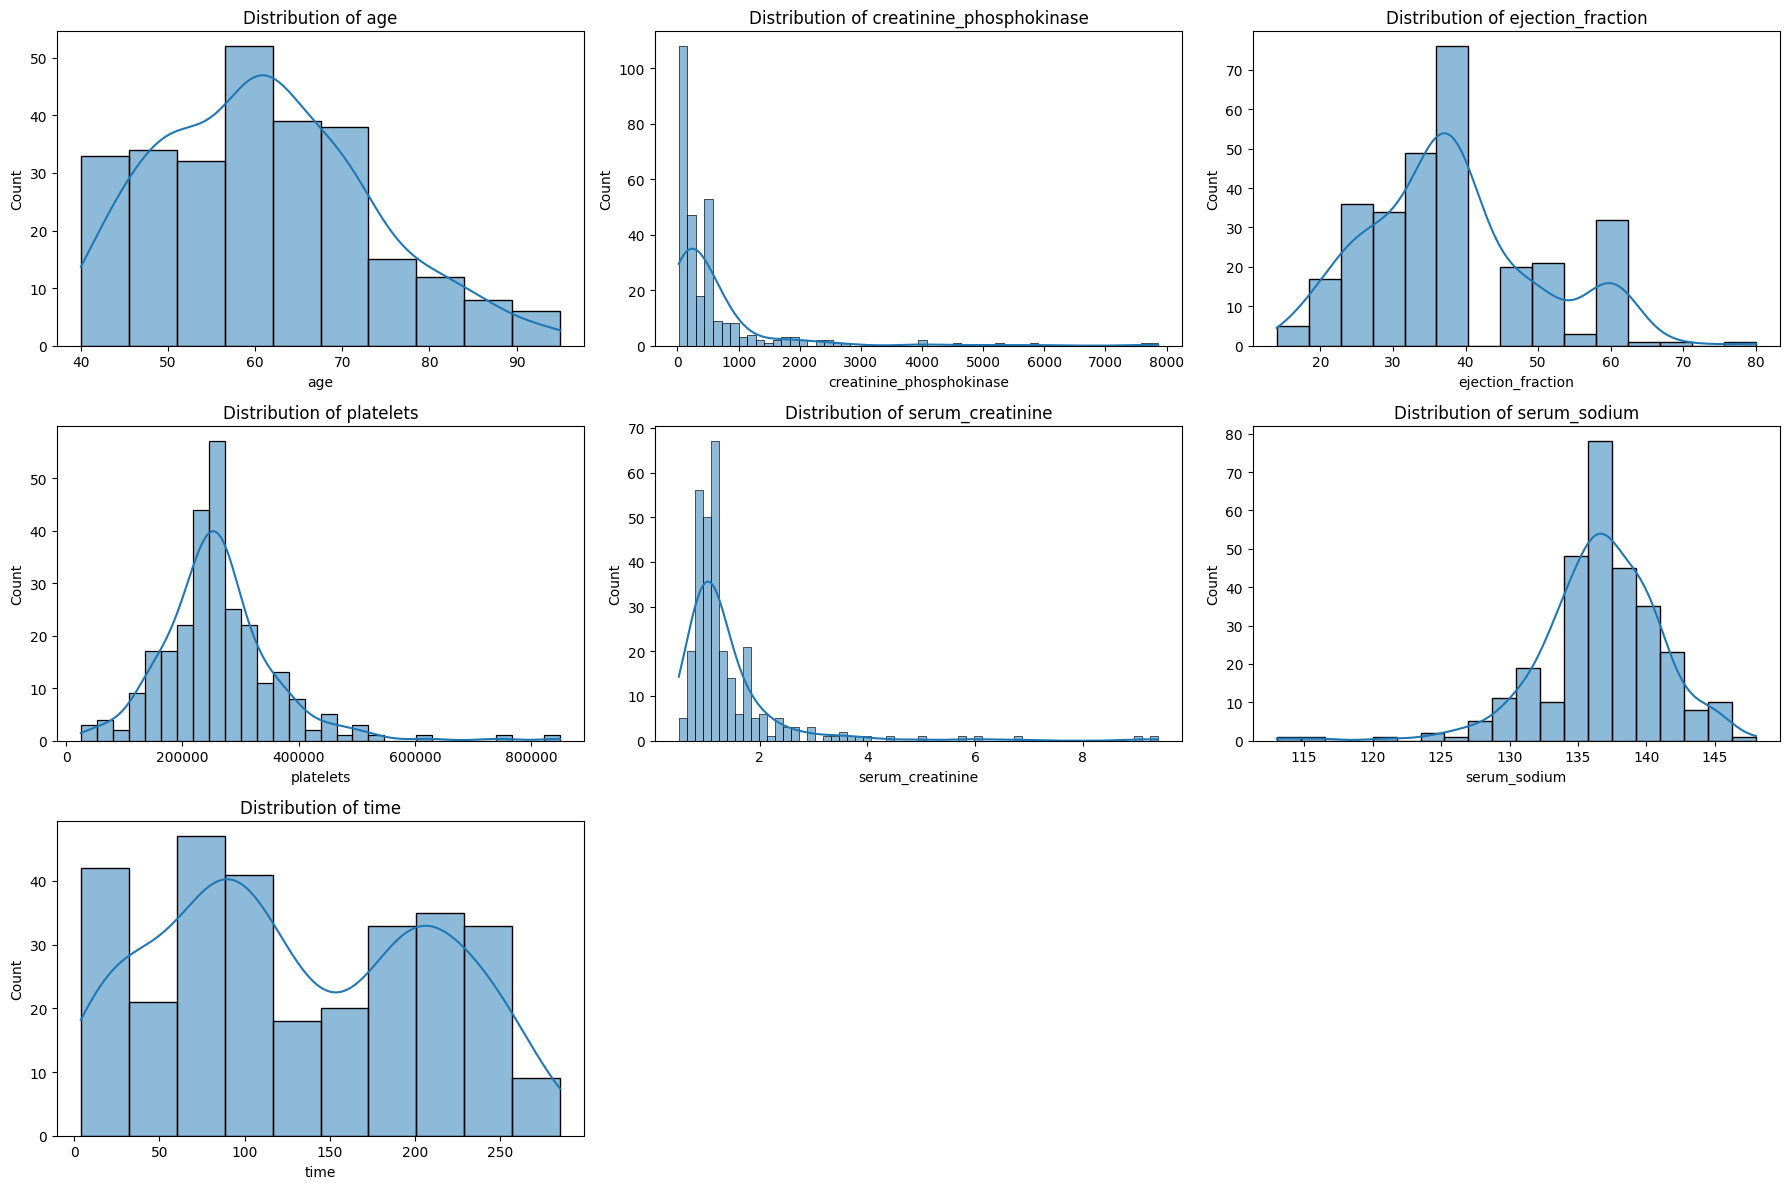

In [ ]:
# Visualisasikan fitur numerik continous (misal : histplot)
continuous_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(continuous_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## BAB 3 – (J.62DMI00.006.1) memvalidasi data

- Pada tahap ini, kita akan mengecek apakah terdapat data yang hilang atau tidak, terdapat duplikat atau tidak, dan apakah terdapat data yang tidak konsisten (bisa melakukan pengecekan nilai unik)

In [ ]:
# Melihat Nilai null / missing value
df.isnull().sum()

,0
age,30
anaemia,0
creatinine_phosphokinase,15
diabetes,0
ejection_fraction,3
high_blood_pressure,0
platelets,30
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
# Melihat Data duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
# Melihat Data yang tidak konsisten (nilai unik per kolom)
for col in df.columns:
    print(f"Unique values for '{col}': {df[col].unique()}")

Unique values for 'age': [75.    55.    65.    50.    90.    60.       nan 80.    62.    45.
 49.    82.    87.    70.    48.    68.    53.    95.    58.    94.
 85.    69.    72.    51.    57.    41.    42.    67.    79.    59.
 44.    63.    86.    43.    46.    61.    81.    52.    64.    40.
 60.667 77.    78.    54.    73.    47.    56.   ]
Unique values for 'anaemia': [0 1]
Unique values for 'creatinine_phosphokinase': [ 582. 7861.  146.  111.  160.   47.  246.   nan  157.  123.   81.  231.
  981.  168.   80.  379.  149.  125.   52.  128.   63.  148.  112.  122.
   60.   70.   23.  249.  159.   94.  855. 2656.  235.  124.  571.  127.
  588. 1380.  553.  129.  577.   91. 3964.   69.  260.  371.   75.  789.
  364. 7702.  318.  109.   68.  110.  161.  113. 5882.  224.   92.  102.
  203.  336.   76.   55.  280.   78.   84.  115.   66.  897.  154.  144.
  133.  514.   59.  156.   61.  305.  898. 5209.   53.  328. 1876.  936.
  292.  369.  143.  754.  400.   96.  737.  358.  200.  248.

## BAB 4 – (J.62DMI00.007.1) menentukan object data

**WAJIB DIISI**,

ADA BERAPA FITUR: 'ISI DISINI'

ADA BERAPA RECORDS: 'ISI DISINI'

ADA BERAPA FITUR YANG TIDAK DIGUNAKAN: 'ISI DISINI'

TARGETNYA APA: 'ISI DISINI'

ADA BERAPA MODEL DATAFRAME YANG HARUS DIBUAT?: 'ISI DISINI

In [ ]:
# Melihat kembali informasi dataset untuk memahami isi dan tipe data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       269 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  284 non-null    float64
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         296 non-null    float64
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 269 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   275 non-null    float64
 11  time                      299 non-null    int64  
 12  death_event               299 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 30.5 KB


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582.0,0,20.0,1,265000.00,1.9,130,1,0.0,4,1
1,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136,1,0.0,6,1
2,65.0,0,146.0,0,20.0,0,162000.00,1.3,129,1,1.0,7,1
3,50.0,1,111.0,0,20.0,0,210000.00,1.9,137,1,0.0,7,1
4,65.0,1,160.0,1,NaN,0,327000.00,2.7,116,0,0.0,8,1


- Jika ada data yang tidak konsisten, silahkan di tangani pada proses dibawah ini.

In [ ]:
# jika terdapat data yang tidak konsisten

- Jika ada fitur yang tidak berguna, bisa dihapus pada cell dibawah ini

In [ ]:
# jika terdapar fitur yang tidak berguna

## BAB 5 – (J.62DMI00.008.1) membersihkan data
- **ANDA TIDAK PERLU MELAKUKAN OUTLIER REMOVAL** NAMUN HANDLE JIKA TERDAPAT DATA YANG KOSONG (TIDAK DIREKOMENDASIKAN MENGHAPUS), HANDLE JIKA ADA DUPLIKAT

In [ ]:
# Memastikan kembali untuk melihat data kosong
df.isnull().sum()

,0
age,30
anaemia,0
creatinine_phosphokinase,15
diabetes,0
ejection_fraction,3
high_blood_pressure,0
platelets,30
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
# Proses handle missing value
# Menggunakan median untuk fitur numerik yang memiliki missing value
df['age'].fillna(df['age'].median(), inplace=True)
df['creatinine_phosphokinase'].fillna(df['creatinine_phosphokinase'].median(), inplace=True)
df['ejection_fraction'].fillna(df['ejection_fraction'].median(), inplace=True)
df['platelets'].fillna(df['platelets'].median(), inplace=True)

# Menggunakan mode untuk fitur 'smoking' yang cenderung kategorikal
df['smoking'].fillna(df['smoking'].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
death_event                 0
dtype: int64


/tmp/ipython-input-1366340570.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipython-input-1366340570.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
# Cek duplikasi data & Handle jika terdapat duplikat data
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_rows}")

if duplicated_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicated rows have been removed.")
else:
    print("No duplicated rows found.")

Number of duplicated rows: 0
No duplicated rows found.


- Dari pekerjaan Membersihkan Data yang telah anda lakukan, Bagaimana yang akan anda lakukan jika Dataset anda ternyata memiliki beberapa nilai kosong (missing value)?

## BAB 6 – (J.62DMI00.009.1) mengkonstruksi data
CATATAN:
- **UNTUK UJIAN INI, ANDA TIDAK PERLU MELAKUKAN FEATURE ENGINEERING DISINI**
- NAMUN ANDA WAJIB MELAKUKAN SAMPLING UNTUK BALANCING CLASS (MENYEIMBANGKAN KELAS DENGAN SKEMA OVER SAMPLING), MENUNJUKKAN OUTLIER YANG TERDAPAT PADA DATASETS, DAN MENAMPILKAN HEATMAP KORELASI ANTAR FITUR UNTUK MENGETAHUI FITUR - FITUR YANG MEMILIKI KORELASI TINGGI DAN RENDAH PADA DATASETS

death_event
0    203
1     96
Name: count, dtype: int64


<Axes: xlabel='death_event', ylabel='count'>

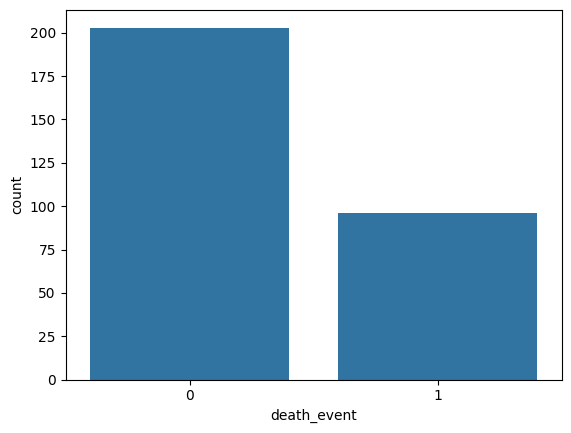

In [ ]:
# visualisasikan persebaran kelas menggunakan countplot
print(df['death_event'].value_counts())
sns.countplot(data=df, x='death_event')

In [ ]:
# karena jumlah kelas target tidak seimbang, kita akan melakukan resampling
from imblearn.over_sampling import SMOTE

X = df.drop('death_event', axis=1)
y = df['death_event']

smote = SMOTE(random_state=42)

In [ ]:
# proses resampling
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
# Menggabungkan Datasets hasil resampling
df_smote = pd.concat([X_smote, y_smote], axis=1)

death_event
1    203
0    203
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of death_event after SMOTE')

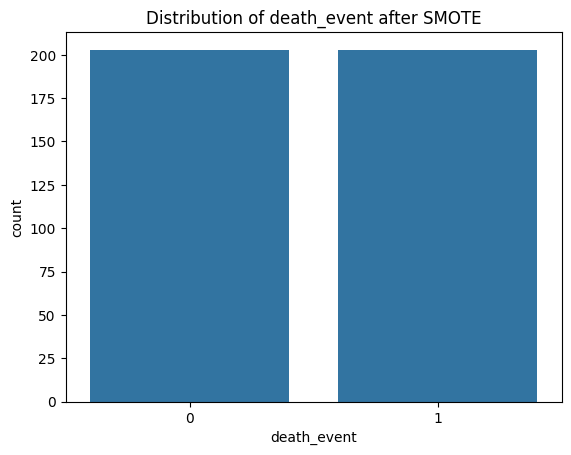

In [ ]:
# Tampilkan visualisasi persebaran kelas setelah melalui proses sampling
print(df_smote['death_event'].value_counts())
sns.countplot(data=df_smote, x='death_event')
plt.title('Distribution of death_event after SMOTE')

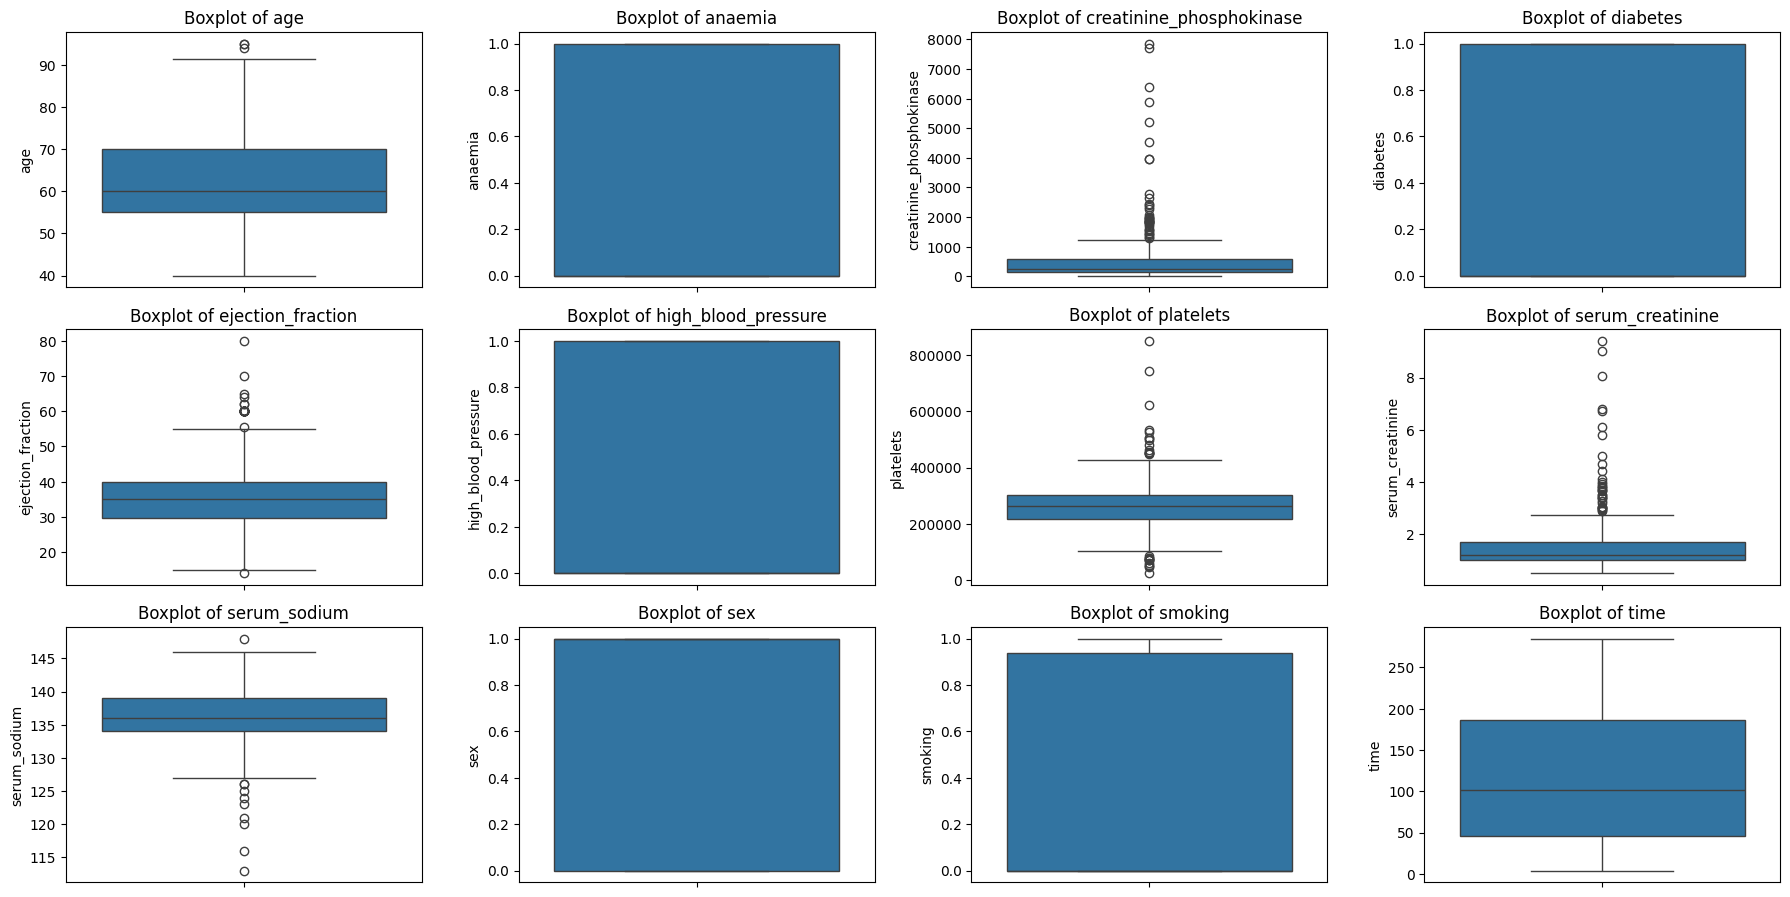

In [ ]:
# cek outlier dengan visualisasi (misalnya menggunakan boxplot)
plt.figure(figsize=(18, 12))
for i, feature in enumerate(df_smote.select_dtypes(include=np.number).columns):
    if feature != 'death_event': # Exclude the target variable from outlier check
        plt.subplot(4, 4, i + 1)
        sns.boxplot(y=df_smote[feature])
        plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

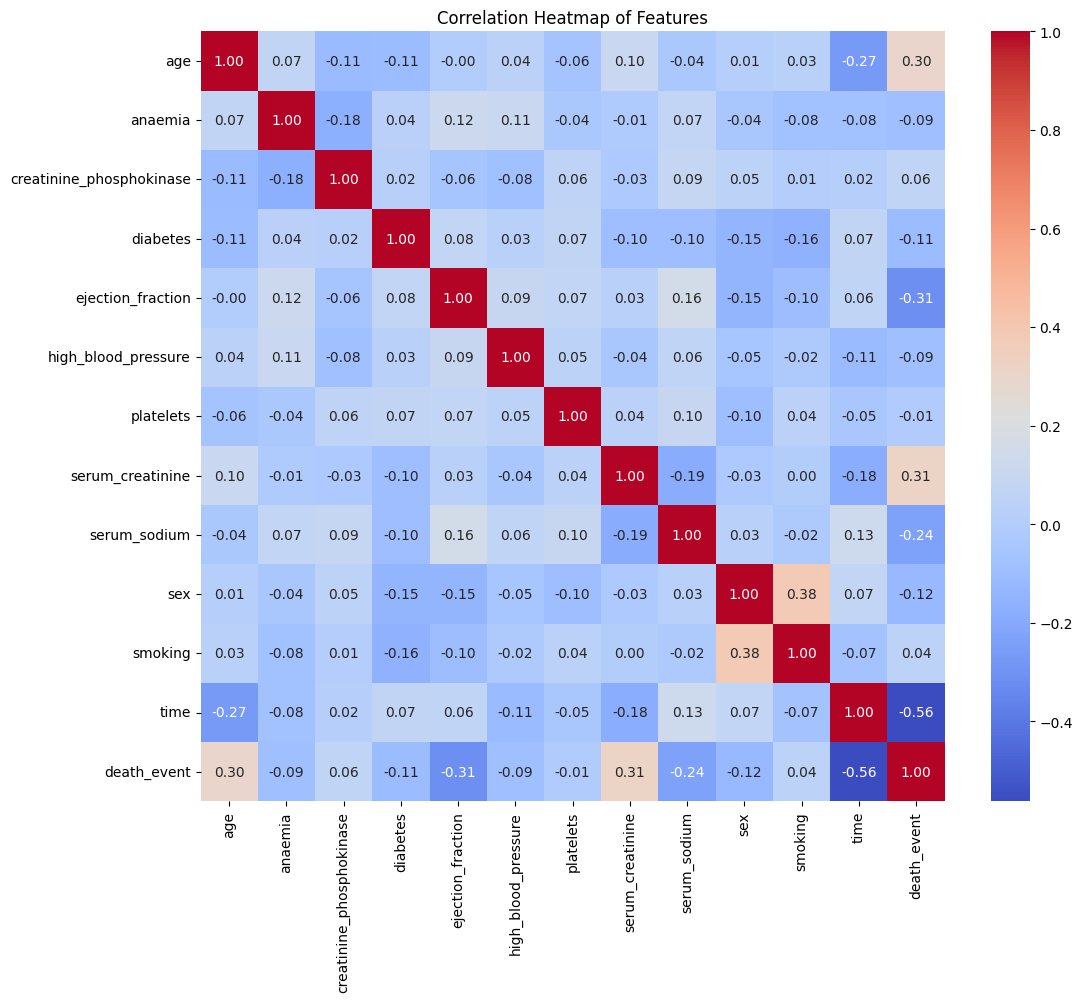

In [ ]:
# melihat korelasi antar fitur (heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(df_smote.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

- DAPAT KITA LIHAT PADA HASIL KORELASI BAHWA `serum_creatinine` dan `ejection_fraction` MEMILIKI KORELASI YANG TINGGI, BAIK ITU POSITIF ATAU NEGATIF.
- PADA TAHAP SELANJUTNYA SILAHKAN BANDINGAN HASIL PEMODELAN KETIKA HANYA MENGGUNAKAN DUA KOLOM TERSEBUT () DENGAN KITA MENGGUNAKAN SEMUA KOLOM.
- SETELAH ITU JAWAB PERTANYAAN BERIKUT :    
  - DARI RATA - RATA SEMUA MODEL YANG DI BANDINGKAN (RF, KNN, DAN LOGISTIC REGRESSION) AKURASI YANG DI DAPATKAN LEBIH TINGGI YANG MENGGUNAKAN 2 FITUR SAJA ATAU SEMUA FITUR? : 'ISI DISINI'

In [ ]:
# ambil hanya 2 fitur serum_creatinine dan ejection_fraction
df_2_fitur = df_smote[['serum_creatinine','ejection_fraction', 'death_event']]
df_2_fitur.head()

,serum_creatinine,ejection_fraction,death_event
0,1.9,20.0,1
1,1.1,38.0,1
2,1.3,20.0,1
3,1.9,20.0,1
4,2.7,38.0,1


In [ ]:
# ambil semua fitur
df_all_fitur = df_smote.copy()
df_all_fitur.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582.0,0,20.0,1,265000.00,1.9,130,1,0.0,4,1
1,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136,1,0.0,6,1
2,65.0,0,146.0,0,20.0,0,162000.00,1.3,129,1,1.0,7,1
3,50.0,1,111.0,0,20.0,0,210000.00,1.9,137,1,0.0,7,1
4,65.0,1,160.0,1,38.0,0,327000.00,2.7,116,0,0.0,8,1


## BAB 7 – (J.62DMI00.010.1) menentukan label data

- Gunakan 2 nama variabel yang berbeda untuk proses splitting dataset baik untuk X,y,train,test contoh :    
  - `X_2_fitur` = Untuk menampung dataset yang akan dimodelkan menggunakan hanya 2 kolom utama.
  - `y_2_fitur` = Untuk menampung target / kelas yang akan diprediksi pada model dengan 2 kolom utama.
  - `X_2_train`,`X_2_test`, `y_2_train`, `y_2_test` = untuk menampung data yang dihasilkan `train_test_split` menggunakan `X_2_fitur` dan `y_2_fitur`

  - `X_all_fitur` = Untuk menampung semua dataset yang akan dimodelkan menggunakan.
  - `y_all_fitur` = Untuk menampung target / kelas yang akan diprediksi pada model dengan semua dataset.
  - `X_all_train`,`X_all_test`, `y_all_train`, `y_all_test` = untuk menampung data yang dihasilkan `train_test_split` menggunakan `X_all_fitur` dan `y_all_fitur`


- yang menjadi target adalah: 'isi disini'
- yang menjadi fitur adalah : 'isi disini'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [ ]:
# Memisahkan fitur dan target dataset 2 fitur
X_2_fitur = df_2_fitur.drop('death_event', axis=1)
y_2_fitur = df_2_fitur['death_event']

In [ ]:
# Memisahkan fitur dan target dataset all fitur
X_all_fitur = df_all_fitur.drop('death_event', axis=1)
y_all_fitur = df_all_fitur['death_event']

- ANDA PERLU MELAKUKAN NORMALISASI DISINI

In [ ]:
# proses normalisasi / scalling
robust_scaler = RobustScaler()

X_2_fitur_scaled = robust_scaler.fit_transform(X_2_fitur)
X_all_fitur_scaled = robust_scaler.fit_transform(X_all_fitur)

- LAKUKAN SPLITTING DISINI

In [ ]:
# Splitting data untuk dataset yang hanya menggunakan 2 fitur
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2_fitur_scaled, y_2_fitur, test_size=0.2, random_state=42)
X_2_train.shape, X_2_test.shape, y_2_train.shape, y_2_test.shape

((324, 2), (82, 2), (324,), (82,))

In [ ]:
# Splitting data untuk dataset yang menggunakan semua fitur
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(X_all_fitur_scaled, y_all_fitur, test_size=0.2, random_state=42)
X_all_train.shape, X_all_test.shape, y_all_train.shape, y_all_test.shape

((324, 12), (82, 12), (324,), (82,))

- Dari pekerjaan Mengkonstruksi Data yang telah anda lakukan, bagaimana cara Anda menentukan fitur-fitur pada dataset anda perlu dinormalisasi atau tidak? : 'ISI DISINI'

## BAB 8 – (J.62DMI00.013.1) membangun model
- BANGUN MODEL DENGAN MENGGUNAKAN ALGORITMA KLASIFIKASI SEPERTI RANDOM FOREST (RF), K-NEAREST NEIGHBOUR (KNN), DAN LOGISTIC REGRESSION (LR) UNTUK KEDUA DATASET (HANYA 2 FITUR & MEMAKAI SEMUA FITUR)

In [ ]:
# Import Library
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
rf_model_2_fitur = RandomForestClassifier(random_state=42)
knn_model_2_fitur = KNeighborsClassifier()
lr_model_2_fitur = LogisticRegression(random_state=42)

rf_model_all_fitur = RandomForestClassifier(random_state=42)
knn_model_all_fitur = KNeighborsClassifier()
lr_model_all_fitur = LogisticRegression(random_state=42)

### Random Forest

Random Forest Classifier 2 fitur
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        41
           1       0.74      0.78      0.76        41

    accuracy                           0.76        82
   macro avg       0.76      0.76      0.76        82
weighted avg       0.76      0.76      0.76        82



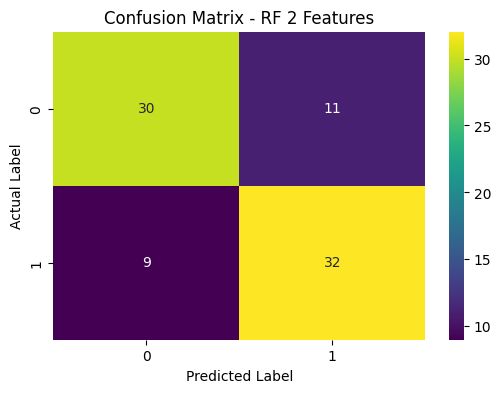

In [ ]:
rf_model_2_fitur.fit(X_2_train, y_2_train)
y_rf_pred_2_fitur = rf_model_2_fitur.predict(X_2_test)

# confusion matrix dan classification report
print("Random Forest Classifier 2 fitur")
print(classification_report(y_2_test, y_rf_pred_2_fitur))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_2_test, y_rf_pred_2_fitur), annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix - RF 2 Features')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Random Forest Classifier all fitur
              precision    recall  f1-score   support

           0       0.92      0.83      0.87        41
           1       0.84      0.93      0.88        41

    accuracy                           0.88        82
   macro avg       0.88      0.88      0.88        82
weighted avg       0.88      0.88      0.88        82



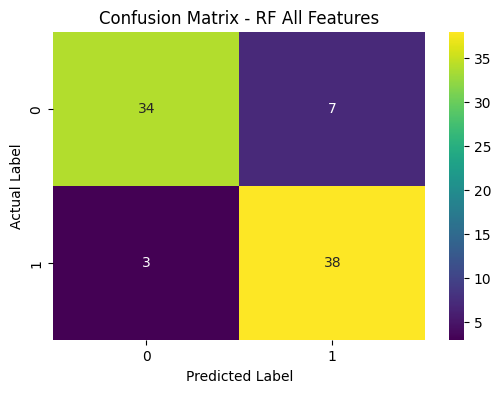

In [ ]:
rf_model_all_fitur.fit(X_all_train, y_all_train)
y_rf_pred_all_fitur = rf_model_all_fitur.predict(X_all_test)

# confusion matrix dan classification report
print("Random Forest Classifier all fitur")
print(classification_report(y_all_test, y_rf_pred_all_fitur))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_all_test, y_rf_pred_all_fitur), annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix - RF All Features')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### KNN

K-Nearest Neighbors Classifier 2 fitur
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        41
           1       0.76      0.76      0.76        41

    accuracy                           0.76        82
   macro avg       0.76      0.76      0.76        82
weighted avg       0.76      0.76      0.76        82



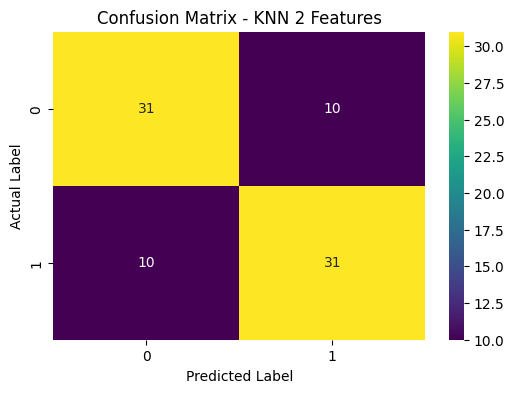

In [ ]:
knn_model_2_fitur.fit(X_2_train, y_2_train)
y_knn_pred_2_fitur = knn_model_2_fitur.predict(X_2_test)

print("K-Nearest Neighbors Classifier 2 fitur")
print(classification_report(y_2_test, y_knn_pred_2_fitur))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_2_test, y_knn_pred_2_fitur), annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix - KNN 2 Features')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

K-Nearest Neighbors Classifier all fitur
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        41
           1       0.82      0.88      0.85        41

    accuracy                           0.84        82
   macro avg       0.84      0.84      0.84        82
weighted avg       0.84      0.84      0.84        82



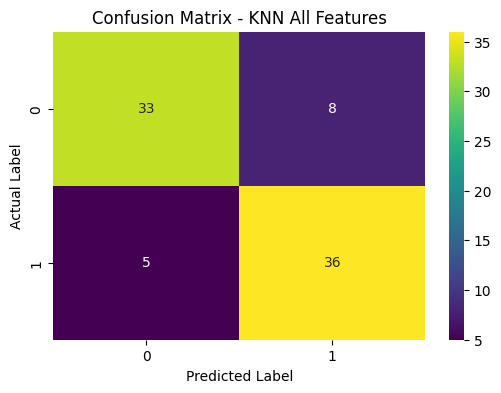

In [ ]:
knn_model_all_fitur.fit(X_all_train, y_all_train)
y_knn_pred_all_fitur = knn_model_all_fitur.predict(X_all_test)

print("K-Nearest Neighbors Classifier all fitur")
print(classification_report(y_all_test, y_knn_pred_all_fitur))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_all_test, y_knn_pred_all_fitur), annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix - KNN All Features')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Logistic Regression

Logistic Regression Classifier 2 fitur
              precision    recall  f1-score   support

           0       0.76      0.85      0.80        41
           1       0.83      0.73      0.78        41

    accuracy                           0.79        82
   macro avg       0.80      0.79      0.79        82
weighted avg       0.80      0.79      0.79        82



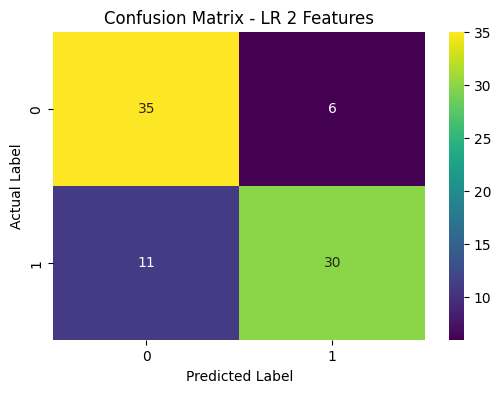

In [ ]:
lr_model_2_fitur.fit(X_2_train, y_2_train)
y_lr_pred_2_fitur = lr_model_2_fitur.predict(X_2_test)

print("Logistic Regression Classifier 2 fitur")
print(classification_report(y_2_test, y_lr_pred_2_fitur))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_2_test, y_lr_pred_2_fitur), annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix - LR 2 Features')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Logistic Regression Classifier all fitur
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        41
           1       0.89      0.78      0.83        41

    accuracy                           0.84        82
   macro avg       0.85      0.84      0.84        82
weighted avg       0.85      0.84      0.84        82



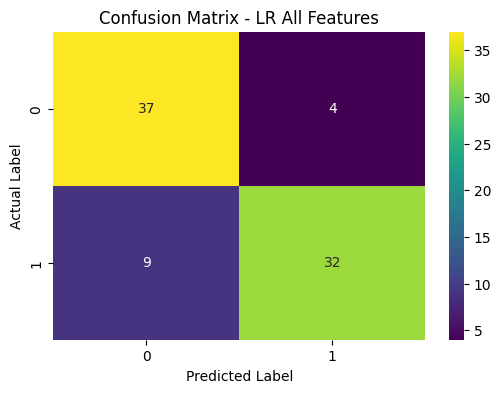

In [ ]:
lr_model_all_fitur.fit(X_all_train, y_all_train)
y_lr_pred_all_fitur = lr_model_all_fitur.predict(X_all_test)

print("Logistic Regression Classifier all fitur")
print(classification_report(y_all_test, y_lr_pred_all_fitur))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_all_test, y_lr_pred_all_fitur), annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix - LR All Features')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

- Dari pekerjaan Membangun Model yang telah anda lakukan, bagaimana cara Anda meningkatkan hasil akurasi pada sebuah model? : 'ISI DISINI'

## BAB 9 – (J.62DMI00.014.1) mengevaluasi hasil pemodelan
- BANDINGKAN SEMUA MODEL UNTUK MENGETAHUI MODEL MANA YANG MEMILIKI AKURASI YANG TINGGI

/tmp/ipython-input-2345536343.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


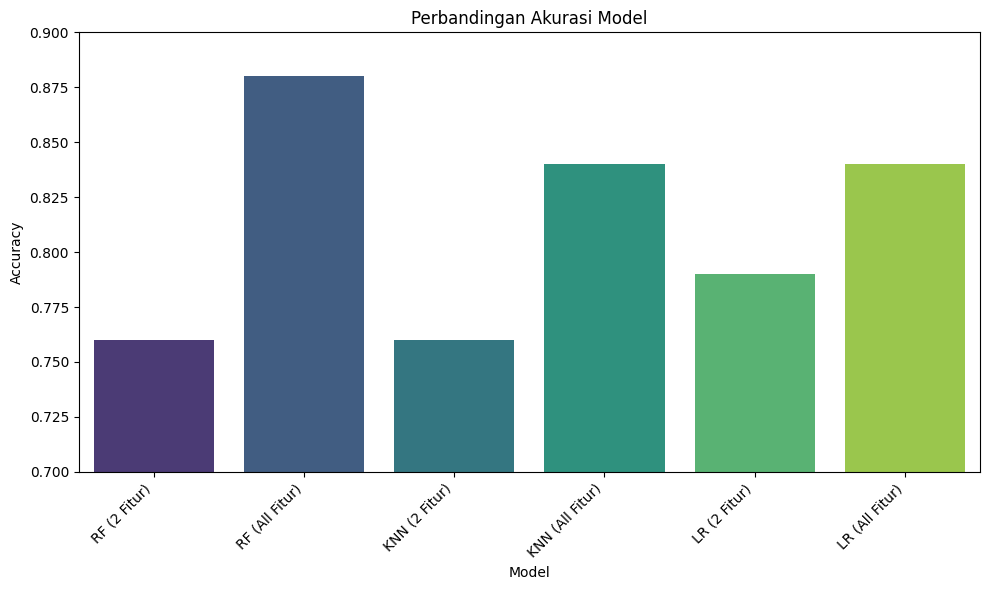

In [ ]:
model_names = ['RF (2 Fitur)', 'RF (All Fitur)', 'KNN (2 Fitur)', 'KNN (All Fitur)', 'LR (2 Fitur)', 'LR (All Fitur)']
accuracies = [
    0.76, # RF 2 fitur
    0.88, # RF all fitur
    0.76, # KNN 2 fitur
    0.84, # KNN all fitur
    0.79, # LR 2 fitur
    0.84  # LR all fitur
]

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Perbandingan Akurasi Model')
plt.ylim(0.70, 0.90) # Set y-axis limits to better visualize differences
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- 3 MODEL YANG MEMILIKI AKURASI TINGGI ? : 'ISI DISINI'
- Dari pekerjaan Mengevaluasi Hasil Pemodelan yang telah anda lakukan, bagaimana cara Anda menentukan model yang lebih akurat dan terbaik dari beberapa model yang telah anda bangun? : 'ISI DISINI'
- Jelaskan

# Penjelasan lebih lanjut mengenai pemilihan model terbaik:
# 1. Akurasi: Meskipun merupakan metrik yang mudah dipahami, akurasi bisa menyesatkan pada dataset yang tidak seimbang. Misalnya, jika 95% data adalah kelas 0, model yang selalu memprediksi kelas 0 akan memiliki akurasi 95%, tetapi tidak berguna.
# 2. Presisi (Precision): Mengukur seberapa banyak prediksi positif yang benar. Penting ketika biaya False Positive tinggi (misalnya, mendiagnosis penyakit pada orang sehat).
# 3. Recall: Mengukur seberapa banyak kasus positif yang berhasil ditangkap oleh model. Penting ketika biaya False Negative tinggi (misalnya, gagal mendiagnosis penyakit pada orang sakit).
# 4. F1-Score: Rata-rata harmonis dari presisi dan recall. Ini adalah metrik yang baik ketika kita ingin menyeimbangkan presisi dan recall, terutama pada dataset yang tidak seimbang.
# 5. Confusion Matrix: Memberikan gambaran detail tentang kinerja model, menunjukkan jumlah True Positives, True Negatives, False Positives, dan False Negatives.
# 6. ROC AUC: Untuk masalah klasifikasi biner, AUC (Area Under the Receiver Operating Characteristic Curve) adalah metrik yang baik untuk mengukur kemampuan model dalam membedakan kelas.
# Dalam kasus ini, karena tujuannya adalah memprediksi kelangsungan hidup pasien gagal jantung, False Negatives (gagal memprediksi kematian) bisa sangat berbahaya. Oleh karena itu, metrik recall untuk kelas 'death_event' (kelas 1) akan sangat penting untuk dipertimbangkan, selain akurasi keseluruhan. Model yang memiliki recall tinggi untuk kelas 1, bersama dengan akurasi yang baik secara keseluruhan, mungkin merupakan pilihan terbaik.